In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, LinearRegression, RidgeClassifier


---
## Što je SVM?
 - perceptron klasificira linearno separabilan skup podataka
 - osim same klasifikacijske hiperravnine, želimo pronaći hiperravninu koja **maksimizira** geometrijsku marginu
 - ako perceptron natreniramo na nekom skupu podataka, velika geometrijska margina nam "osigurava" da nove, neviđene točke budu točno klasificirane
 - kako bismo pronašli takvu hiperravninu, moramo postaviti nekakav optimizacijski problem
 - ako su podaci linearno separabilni hiperravninom kroz ishodište, onda postoje $\Theta \in \mathbb{R}^n$ i $\gamma > 0$ takvi da $y^{(i)}\Theta^T x^{(i)} \geq \gamma, \text{ } i = 1, 2, \dots, m$
 - optimizacijski problem možemo postaviti kao
 $$
 \textrm{argmax}_{\gamma, \Theta}\frac{\gamma}{||\Theta||}
 $$
 
 $$
 \text{  uz uvjet  } y^{(i)}\Theta^T x^{(i)} \geq \gamma, \text{ }  i = 1, 2, \dots, m,
 $$
 što se može svesti na 
 $$
 \textrm{argmin}_{\gamma, \Theta}\frac{1}{2}\left(\frac{||\Theta||}{\gamma}\right)^2
 $$
 
 $$
 \text{  uz uvjet  } y^{(i)}\Theta^T x^{(i)} \geq \gamma, \text{ }  i = 1, 2, \dots, m,
 $$
 odnosno
 $$
 \textrm{argmin}_{\Theta}\frac{1}{2}||\Theta||^2
 $$
 
 $$
 \text{  uz uvjet  } y^{(i)}\Theta^T x^{(i)} \geq 1, \text{ }  i = 1, 2, \dots, m,
 $$
 
 - problem se može generalizirati na hiperravninu koja ne prolazi ishodištem
 $$
 \textrm{argmin}_{\Theta, \theta_0}\frac{1}{2}||\Theta||^2
 $$
 
 $$
 \text{  uz uvjet  } y^{(i)}(\Theta^T x^{(i)} + \theta_0) \geq 1, \text{ }  i = 1, 2, \dots, m,
 $$
 
 - ako podaci **nisu linearno separabilni**, dozvoljavamo kršenje uvjeta, ali uz penalizaciju koju je potrebno minimizirati
 $$
 \textrm{argmin}_{\Theta, \theta_0, \xi_i}\frac{1}{2}||\Theta||^2 + C\sum\limits_{i=1}^m \xi_i
 $$
 
 $$
 \text{  uz uvjet  } y^{(i)}(\Theta^T x^{(i)} + \theta_0) \geq 1 - \xi_i \textrm{ i } \xi_i \geq 0, \text{ }  i = 1, 2, \dots, m,
 $$
 

### Scikit-learn implementacija SVM-a
Dostupne su implementacije nekoliko algoritama: [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC), [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) i [NuSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.NuSVC.html#sklearn.svm.NuSVC).

Implementacije se razlikuju po algoritmima koje koriste. SVC koristi libsvm, dok LinearSVC koristi liblinear te je puno efikasniji za veći broj podataka.

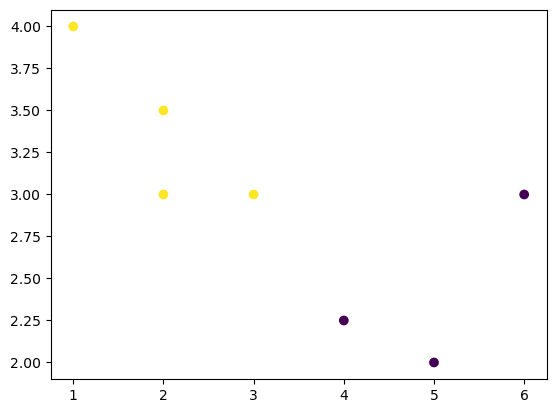

In [2]:
X = np.array([[2,3.5], 
              [2,3], 
              [1,4], 
              [3,3], 
              [5,2], 
              [4,2.25], 
              [6,3]])
y = np.array([1, 
              1, 
              1, 
              1, 
              -1, 
              -1, 
              -1])
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()



In [4]:
#bitno da je y ili -1 ili 1, ne smije biti 0
clf = SVC(kernel = "linear")
clf.fit(X,y)
#theta
print(clf.coef_)
print(clf.intercept_)
#margina?
print(1/np.linalg.norm(clf.coef_))

[[-1.    0.75]]
[1.53125]
0.8


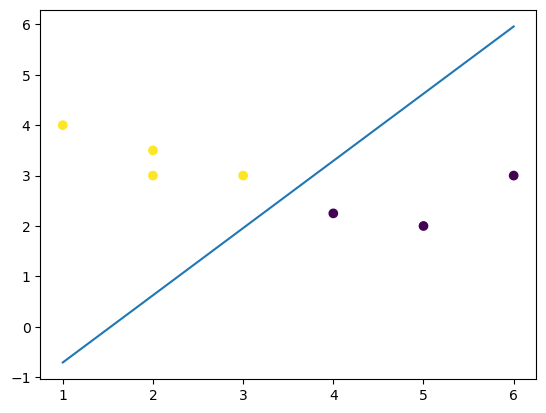

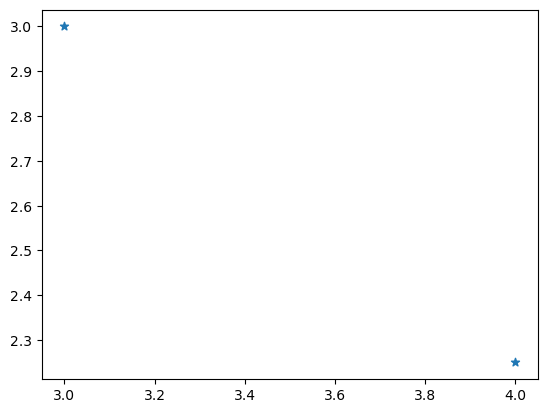

In [8]:
xx = np.linspace(1,6,100)
yy = -(clf.coef_[0][0]/clf.coef_[0][1]) * xx - clf.intercept_/clf.coef_[0][1]
plt.plot(xx,yy)
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

#plottamo support vectore
clf.support_vectors_
plt.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1], marker = "*")

### Testiranje SVC i LinearSVC-a

In [12]:
x,y = make_blobs(n_samples=1000, centers = [(2,2),(-2,-2)], n_features=2)
#pretvoriti y u -1 i 1, po defaultu nisu
y[y==0]=-1
#random state producira uvijek iste podatke, za randomness trebamo bez njega

In [13]:
%%timeit
clf=SVC()
clf.fit(x,y)

772 µs ± 16.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [14]:
%%timeit
clf2= LinearSVC()
clf2.fit(x,y)

/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will c

430 µs ± 7.04 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will c

### Zadatak
Generirajte $10^5$ točaka i usporedite brzinu SVC i LinearSVC algoritama. Koristite `%%timeit` cell magic umjesto `%%time` da dobijete prosječno vrijeme izvršavanja.

Nakon vježbi pokušajte generirati $10^6$ točaka i provedite isti test.

### LinearSVC ne računa potporne vektore

Za razliku od metode `SVC`, model `LinearSVC` ne vraća direktno potporne vektore.  
Zato ih možemo aproksimirati koristeći funkciju odluke:
$$
f(x) = \Theta^T x + \theta_0
$$

Kod SVM-a vrijedi uvjet:
$$
y_i (\Theta^T x_i + \theta_0) \geq 1
$$

U **soft-margin** varijanti (koju koristi `LinearSVC`) dopuštamo odstupanja, pa su potporni vektori sve točke za koje vrijedi:
$$
y_i (\Theta^T x_i + \theta_0) \leq 1
$$

To uključuje:
- točke koje leže točno na margini  
- točke unutar margine  
- čak i pogrešno klasificirane točke  

---

### Vizualizacija

Vrijednosti funkcije odluke definiraju:
- $f(x) = 0$ → granica odluke (decision boundary)  
- $f(x) = \pm 1$ → margine  

---

### Utjecaj parametra C

Parametar $C$ kontrolira kompromis između:
- širine margine  
- tolerancije na pogreške  

- **manji $C$** → šira margina, više točaka unutar margine  
- **veći $C$** → uža margina, strože razdvajanje  

Zbog toga se s promjenom $C$ mijenja i broj potpornih vektora.

/usr/lib/python3/dist-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


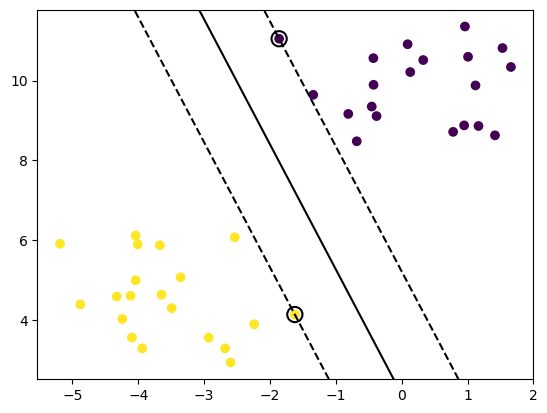

In [28]:

X,y = make_blobs(n_samples=40,centers= 2)
y[y==0]=-1
clf=LinearSVC(C=1000, random_state=42)
clf.fit(X,y)

#racunamo koji vektori su u margini (<=)
dec_func=clf.decision_function(X)
#na kojim mjestima se nalaze unutar x-a
#support_vector_indices=(y*dec_func<=1) #ovo je dobro in general, ali zbog preciznosti dodajemo numpy funkciju koja malo bolje pazi na nejednaost
support_vector_indices=np.where(y*dec_func<=1 + 1e-15)
support_vectors = X[support_vector_indices] #uzmi sve podatke i od indexa tih podataka

plt.scatter(X[:, 0], X[:, 1], c=y)
ax = plt.gca()

# granice grafa
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# grid
xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], 500),
    np.linspace(ylim[0], ylim[1], 500)
)

# decision function po gridu
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# decision boundary i margine
plt.contour(xx, yy, Z,
            levels=[-1, 0, 1],
            linestyles=['--', '-', '--'],
            colors='k')

# support vectors (kružnice)
plt.scatter(support_vectors[:, 0], support_vectors[:, 1],
            s=120, linewidth=1.5,
            facecolors='none', edgecolors='k')


## Što je logistička regresija?
- za model funkciju koristimo logističku (sigmoidnu) funkciju $\sigma : \mathbb{R} \to \mathbb{R}$, zadanu s $\sigma(x) = \frac{1}{1+\exp{(-x)}}$
- model funkcija je oblika $h_{\Theta}(x) = \sigma(\Theta^Tx) = \frac{1}{1+\exp{(-\Theta^Tx)}}$, eventualno s dodatnim parametrom $\theta_0$.
- logistička funkcija preslikava cijeli $\mathbb{R}$ na interval $\langle 0,1 \rangle$ pa izlaznu vrijednost interpretiramo kao vjerojatnost da podatak $x$ s obzirom na parametar $\theta$ pripada klasi $1$
- kao u SVM ili perceptron modelu, $\Theta$ definira hiperravninu koja klasificira podatke, sve što je "ispod" je klasa 0, sve "iznad" klasa 1
- Učenje se svodi na minimizaciju **konveksne** funkcije cilja 
$$
J(\Theta) = \sum_{i=1}^m\log{}(1 + \exp(-y^{(i)}\Theta^Tx^{(i)})),
$$
što postižemo primjenom gradijentne metode ili nekog drugog optimizacijskog algoritma.

In [29]:
#iscrtavanje podataka, njihovih klasa i granice odluke 
def lr_contour(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 1000),
                         np.linspace(ylim[0], ylim[1], 1000))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap='spring', alpha=0.2)
    plt.show()

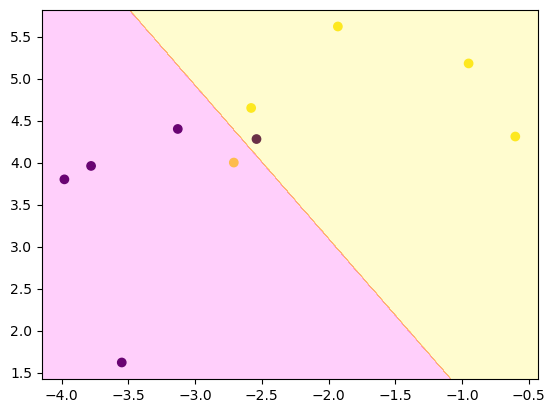

In [30]:
X = np.array([[-3.78,3.96],
              [-3.98,3.8],
              [-0.95,5.18],
              [-2.71,4],
              [-0.6,4.31],
              [-2.58,4.65],
              [-2.54,4.28],
              [-3.55,1.62],
              [-3.13,4.4],
              [-1.93,5.62]])
y = np.array([-1, 
              -1, 
              1, 
              1, 
              1, 
              1, 
              -1, 
              -1, 
              -1, 
              1])
lr=LogisticRegression().fit(X,y)
lr_contour(X,y,lr)

## Linearna regresija kao klasifikacijski model
Neka su zadani podaci (u obliku matrice dizajna) $X\in \mathbb{R}^{m \times n}$ i njihove pripadne klase $y\in \{-1,1\}^m$. Pokušajmo riješiti problem učenjem modela linearne regresije.

Tražimo parametre $\Theta \in \mathbb{R}^n, \theta_0 \in \mathbb{R}$ takve da minimiziraju funkciju cilja 
$$
J(\Theta, \theta_0) = \sum\limits_{i=1}^m (h_{\Theta, \theta_0}(x^{(i)}) - y^{(i)})^2,$$
gdje je $h_{\Theta, \theta_0}(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$. 

Vrijednost model-funkcije koristimo za interpretaciju pripadnosti klase:
 - ako je $h_{\Theta, \theta_0}(x) > 0$, onda je $y = 1$,
 - ako je $h_{\Theta, \theta_0}(x) < 0$, onda je $y = -1$.

In [ ]:
X,y=make_blobs(n_samples=10000, n_features=2, centers=2, random_state=431) # ovaj state daje linearno neseparabilne podatke
y[y==0]=-1
#razdvajamo podatke na trening i test skup
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=431)
lr= LinearRegression().fit(X_train, y_train)
log=LogisticRegression().fit(X_train, y_train)
rgd = RidgeClassifier().fit(X_train, y_train)

array([-1, -1, -1, ...,  1, -1, -1])